## Housing data
Data is Housing Price Index from SNB. All values are relative to year 2000 prices (2000 = 100%)

In [3]:
from data_ingestion import get_clean_housing_data

dfs = get_clean_housing_data()
housing_df = dfs['housing_df']
housing_df.head()

,date,Privately owned apartments - Asking price,Privately owned apartments - Transaction price,Single-family houses - Asking price,Single-family houses - Transaction price,Apartment buildings (residential investment property) - Transaction price,Rents - Industrial and commercial space,Rents - Office space,Rents - Rental housing units,Rents - Retail space
0,1970-01-01,37.067421,NaN,36.476339,NaN,NaN,46.120740,48.588164,34.664977,57.492516
1,1971-01-01,40.041925,NaN,41.771233,NaN,NaN,54.266010,52.454522,40.164850,54.101961
2,1972-01-01,45.192274,NaN,50.331605,NaN,NaN,56.381710,59.946112,45.606831,72.492423
3,1973-01-01,51.021098,NaN,59.446265,NaN,NaN,66.659691,64.896925,50.334182,76.553432
4,1974-01-01,50.419630,NaN,59.588616,NaN,NaN,63.007929,65.482283,53.390472,72.950228


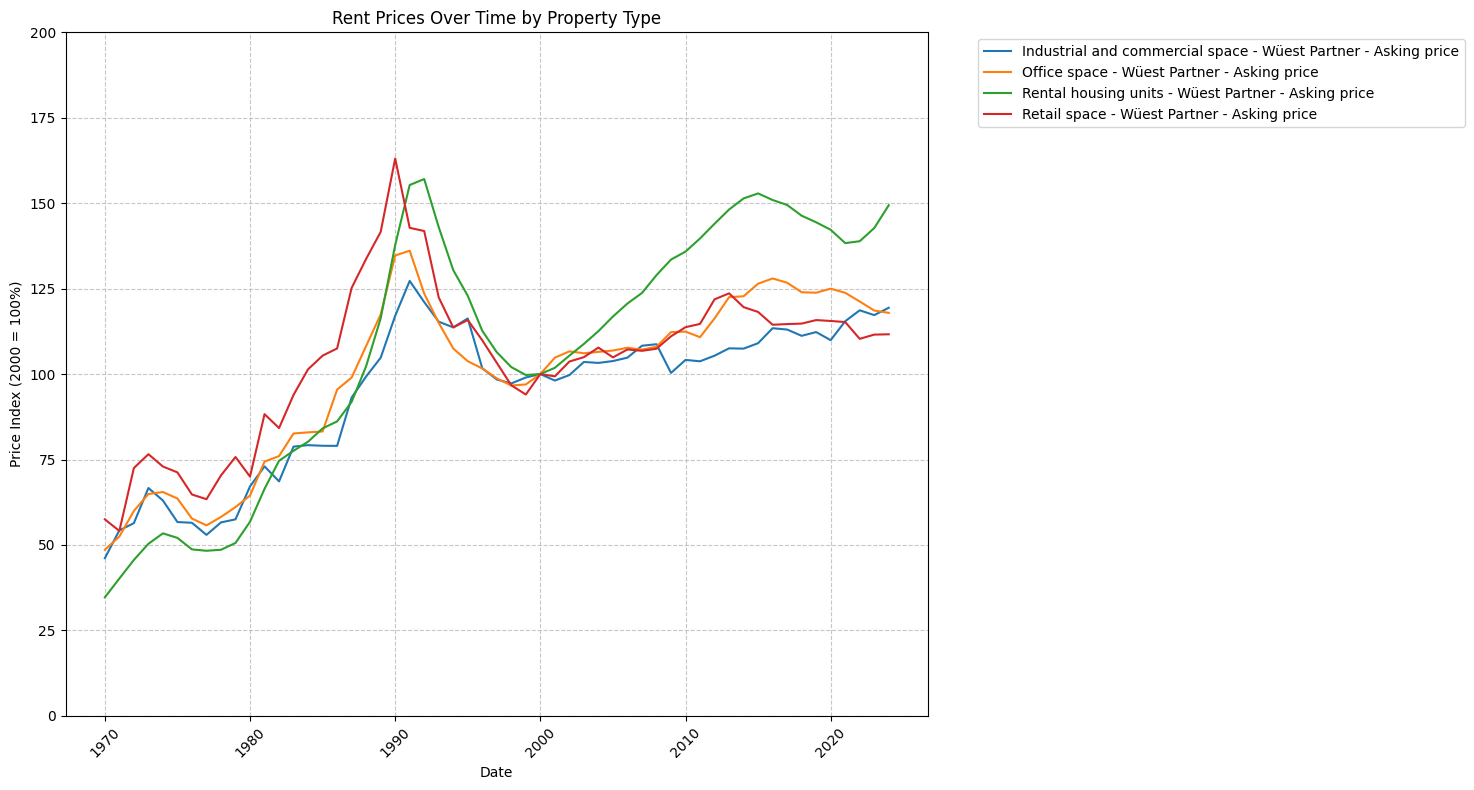

In [4]:
import matplotlib.pyplot as plt

rents_df = dfs['rents_df']

# Create figure and axis
plt.figure(figsize=(15, 8))

# Plot each rent type
rent_columns = []

for col in rents_df.columns:
    if col == 'date':
        continue
    rent_columns.append(col)

for column in rent_columns:
    plt.plot(rents_df['date'], rents_df[column], label=column.replace('Rents - ', ''))

# Customize plot
plt.title('Rent Prices Over Time by Property Type')
plt.xlabel('Date')
plt.ylabel('Price Index (2000 = 100%)')
plt.ylim([0, 200])
plt.yticks(range(0, 201, 25))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tick_params(axis='x', rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

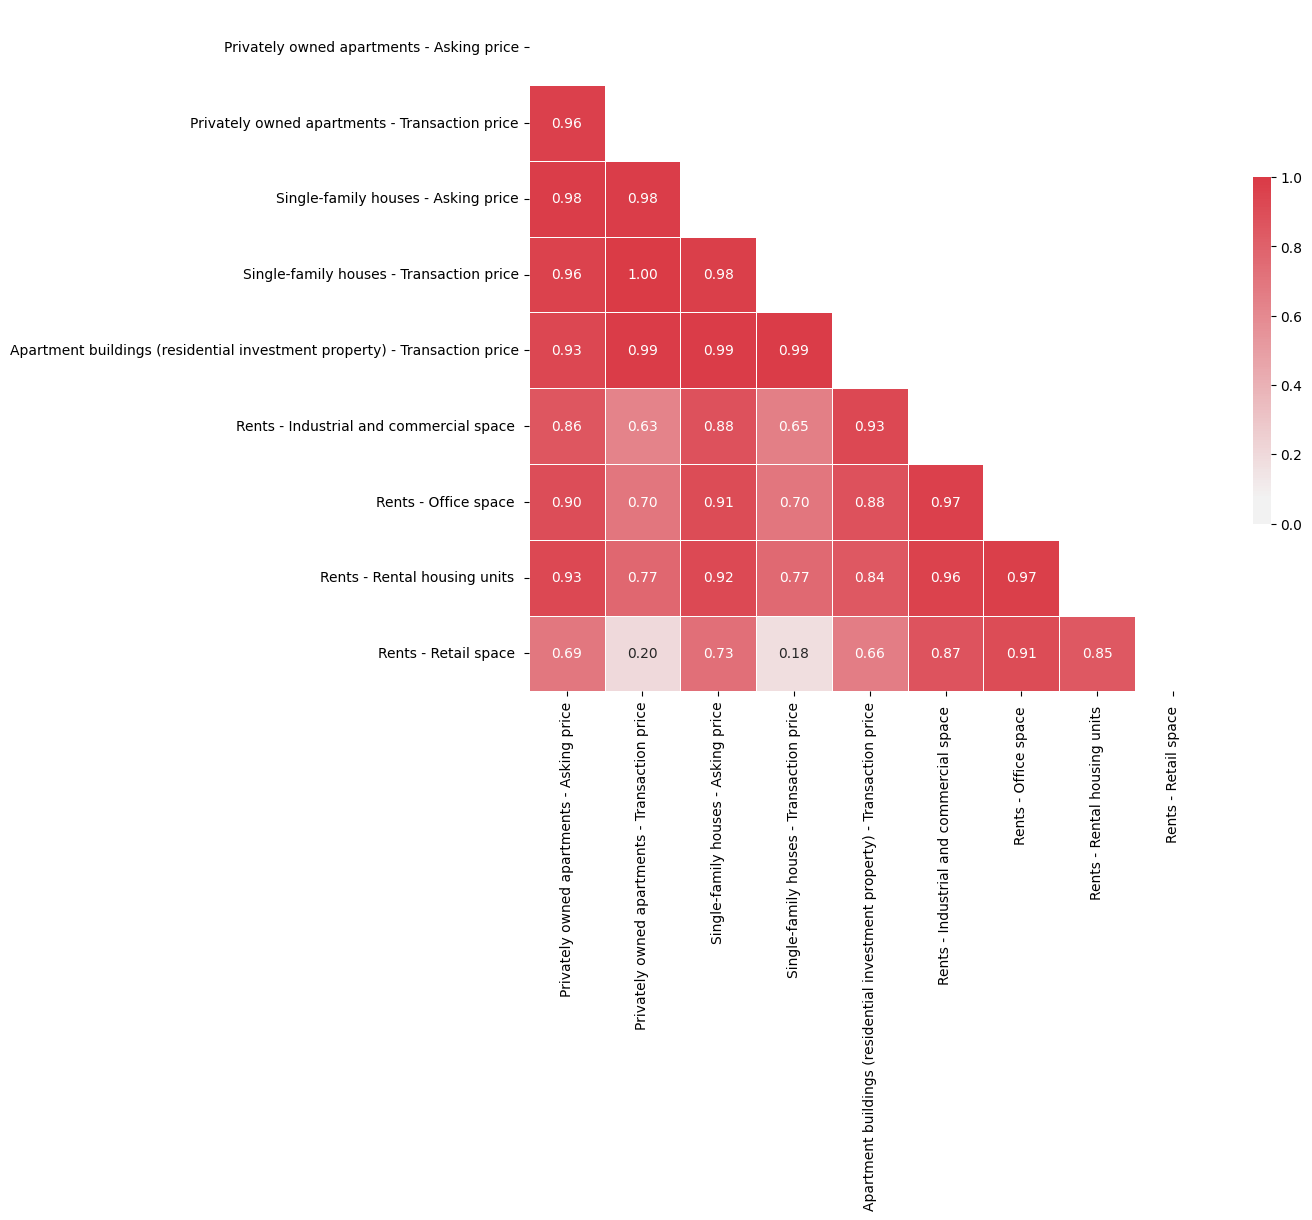

<Axes: >

In [ ]:
from visualization_function import plot_correlation_heatmap

# Use the function with the statistics dataframe
plot_correlation_heatmap(housing_df, vmin=0)

## Importing Demographics Data:
Live births  
Deaths  
Natural Change  
Immigration  
Emigration  
Net migration  
Acquisition of Swiss citizenship

In [ ]:
from data_ingestion import get_demographics_data, long_to_wide_demographics

raw_demographics_df = get_demographics_data()
demographics_df = long_to_wide_demographics(raw_demographics_df)
demographics_df.head()

POPULATION_CHANGE_COMPONENT,date,Acquisition of Swiss citizenship,Deaths,Emigration,Immigration,Live births,Natural Change,Net migration,Statistical adjustments
0,1861-01-01,NaN,57520.0,NaN,NaN,74820.0,17300.0,381.0,NaN
1,1862-01-01,NaN,51070.0,NaN,NaN,75870.0,24800.0,-3620.0,NaN
2,1863-01-01,NaN,54360.0,NaN,NaN,79160.0,24800.0,-3408.0,NaN
3,1864-01-01,NaN,59500.0,NaN,NaN,79600.0,20100.0,-1194.0,NaN
4,1865-01-01,NaN,59090.0,NaN,NaN,78290.0,19200.0,-2653.0,NaN


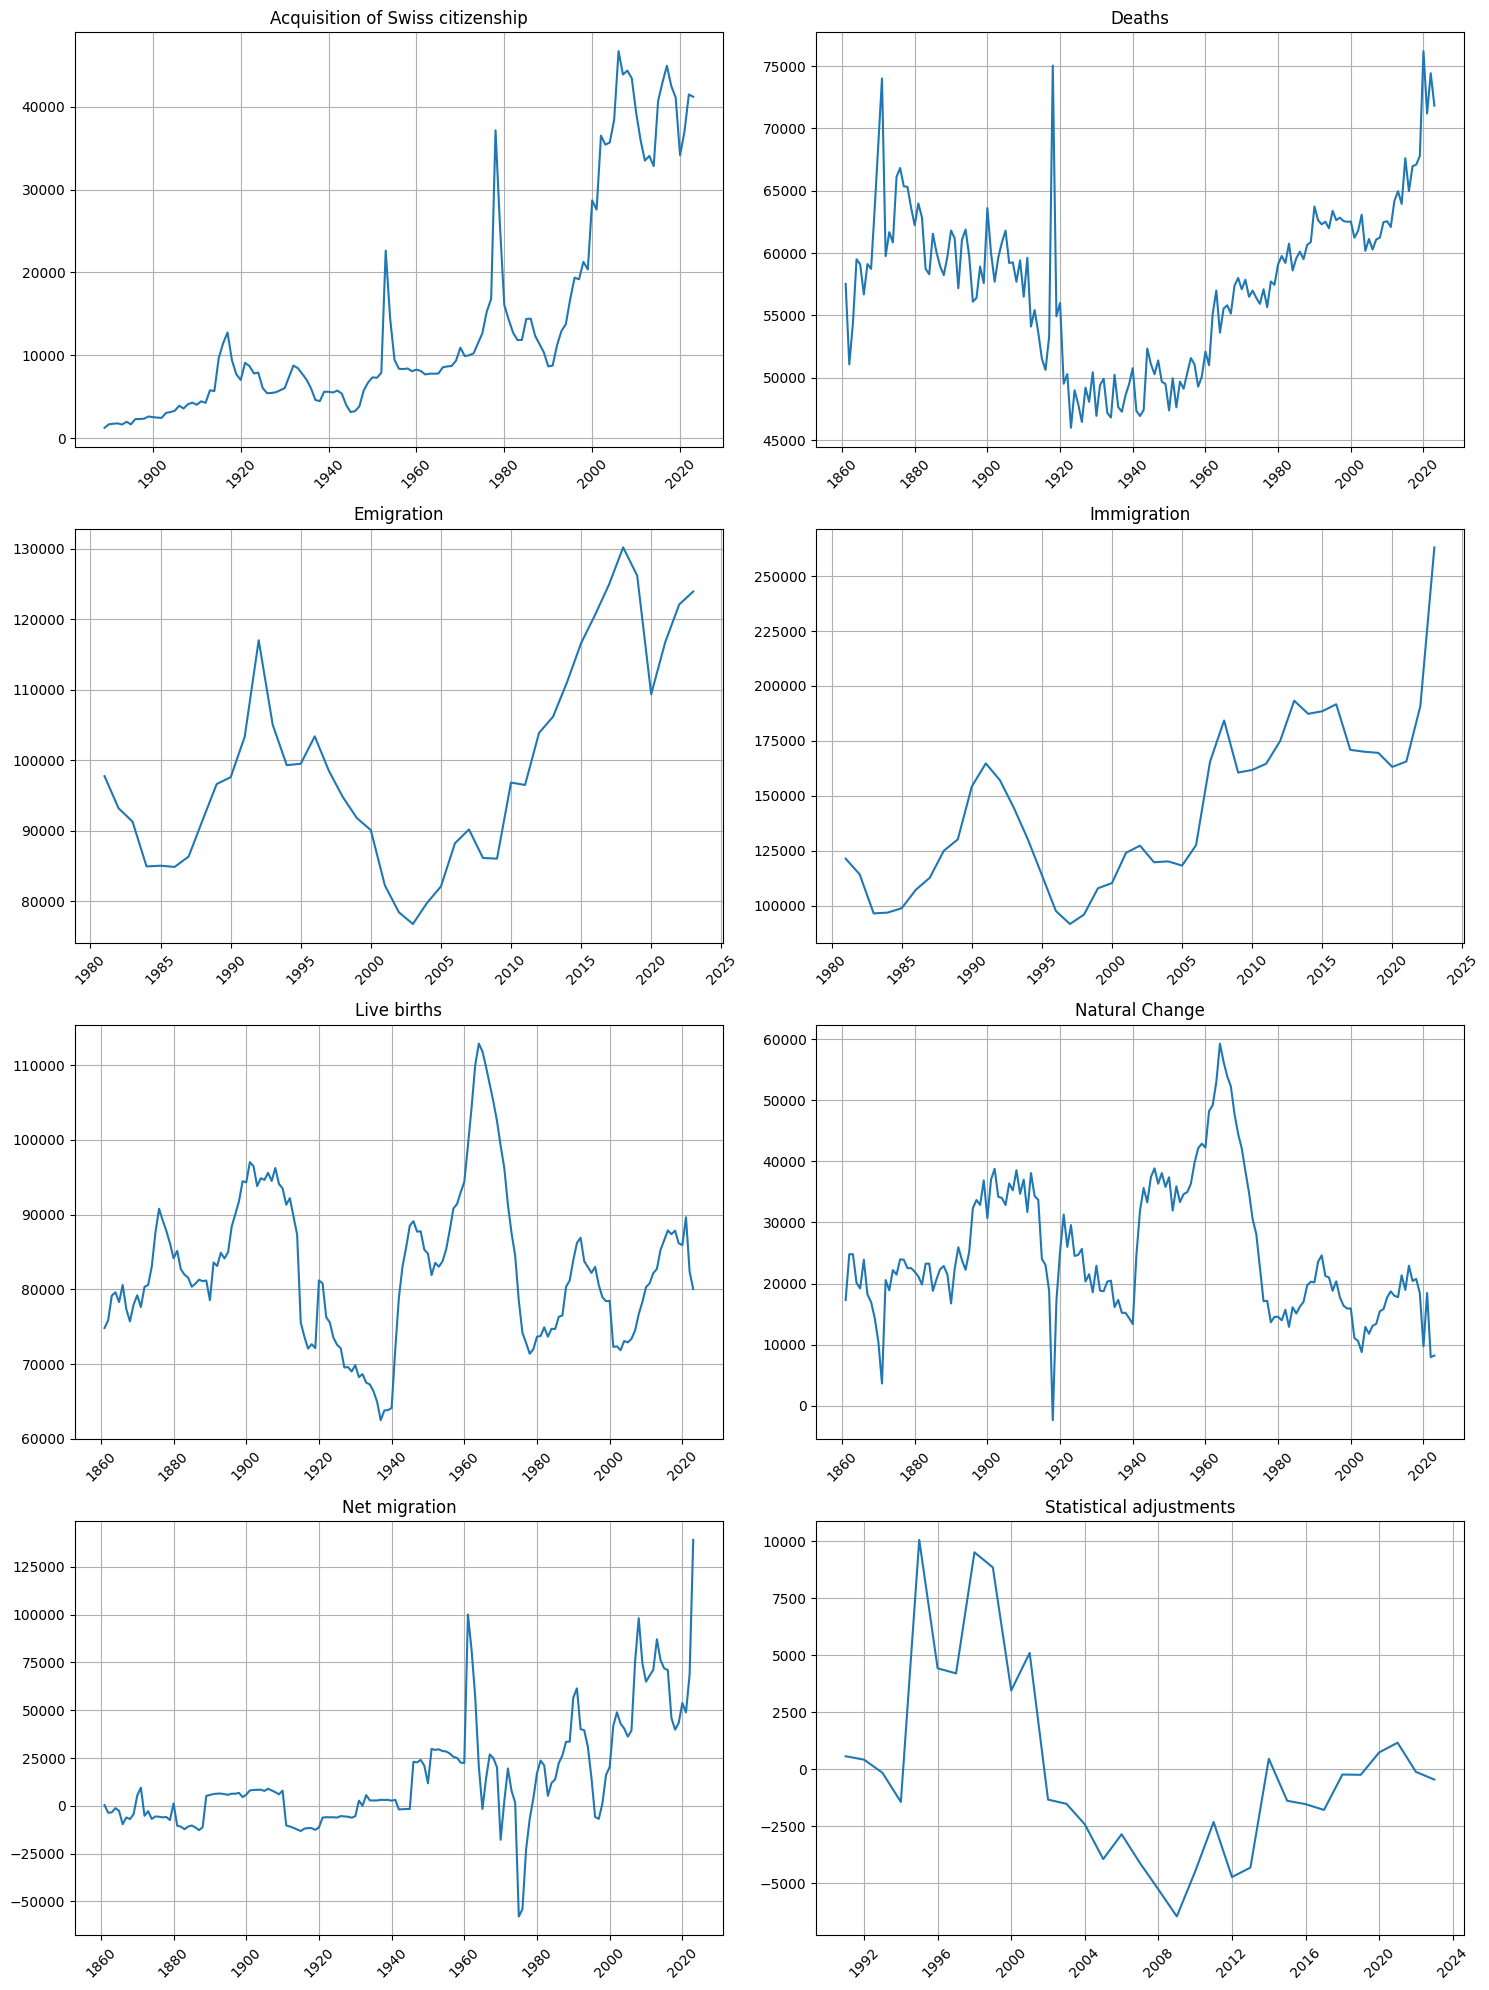

In [ ]:
from visualization_function import plot_all_columns

plot_all_columns(demographics_df)

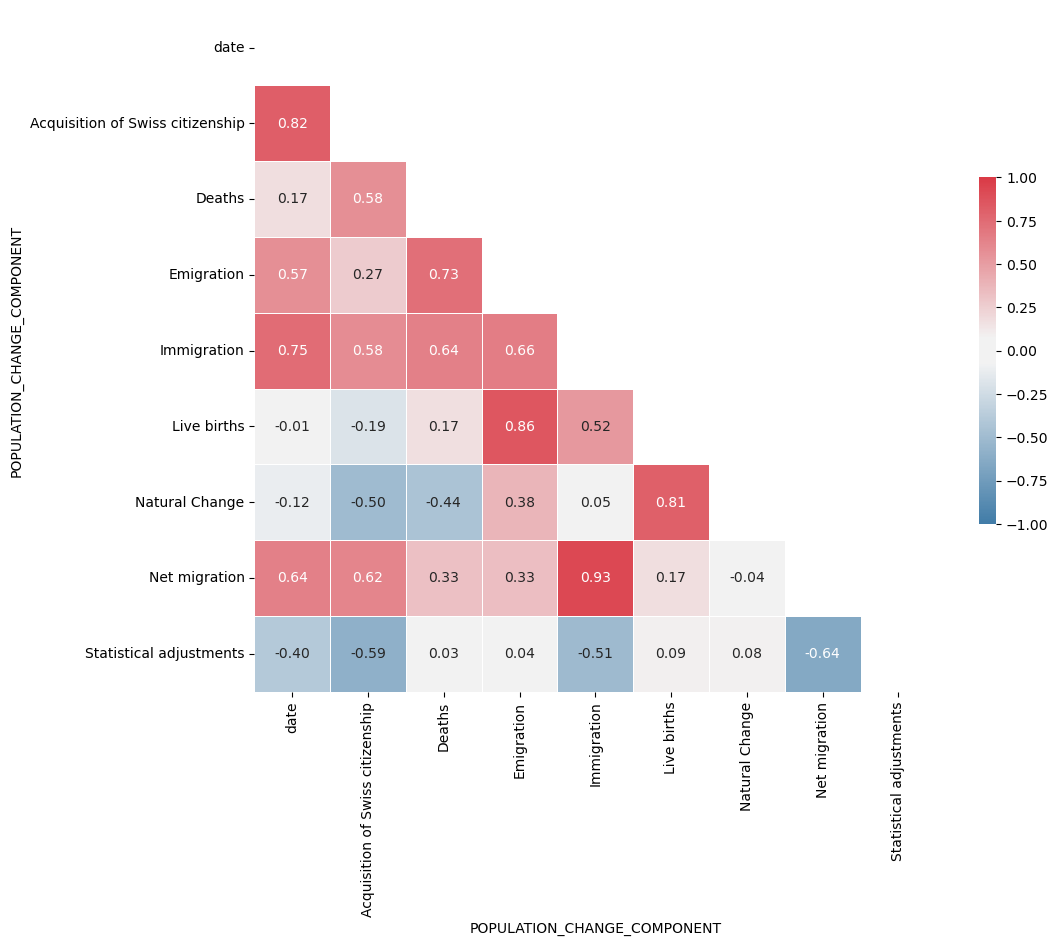

In [ ]:
from visualization_function import plot_correlation_heatmap

plot_correlation_heatmap(demographics_df, vmin=-1)

## Importing Monetary Data

### Interest rates

In [3]:
from data_ingestion import get_and_process_snb_data, group_data_by_year

interest_rates_df = get_and_process_snb_data(url="https://data.snb.ch/api/cube/zimoma/data/json/en")
yearly_interest_rates_df=group_data_by_year(interest_rates_df)
yearly_interest_rates_df.head()

,date,Switzerland - CHF - SARON - 1 day,Switzerland - CHF - Call money rate (Tomorrow next) - 1 day,Switzerland - CHF - Money market debt register claims of the Swiss Confederation - 3-month,Switzerland - CHF - CHF LIBOR - 3-month,United States - USD - SOFR - 1-day,United States - USD - USD LIBOR - 3-month,Japan - JPY - TONA - 1-day,Japan - JPY - JPY LIBOR - 3-month,United Kingdom - GBP - SONIA - 1-day,United Kingdom - GBP - GBP LIBOR - 3-month,Euro area - EUR - ESTR - 1-day,Euro area - EUR - EURIBOR - 3-month,Euro area - EUR - EUR LIBOR - 3-month
0,1972-01-01,NaN,1.18750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1973-01-01,NaN,3.67708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1974-01-01,NaN,2.91667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1975-01-01,NaN,1.30208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1976-01-01,NaN,0.41667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


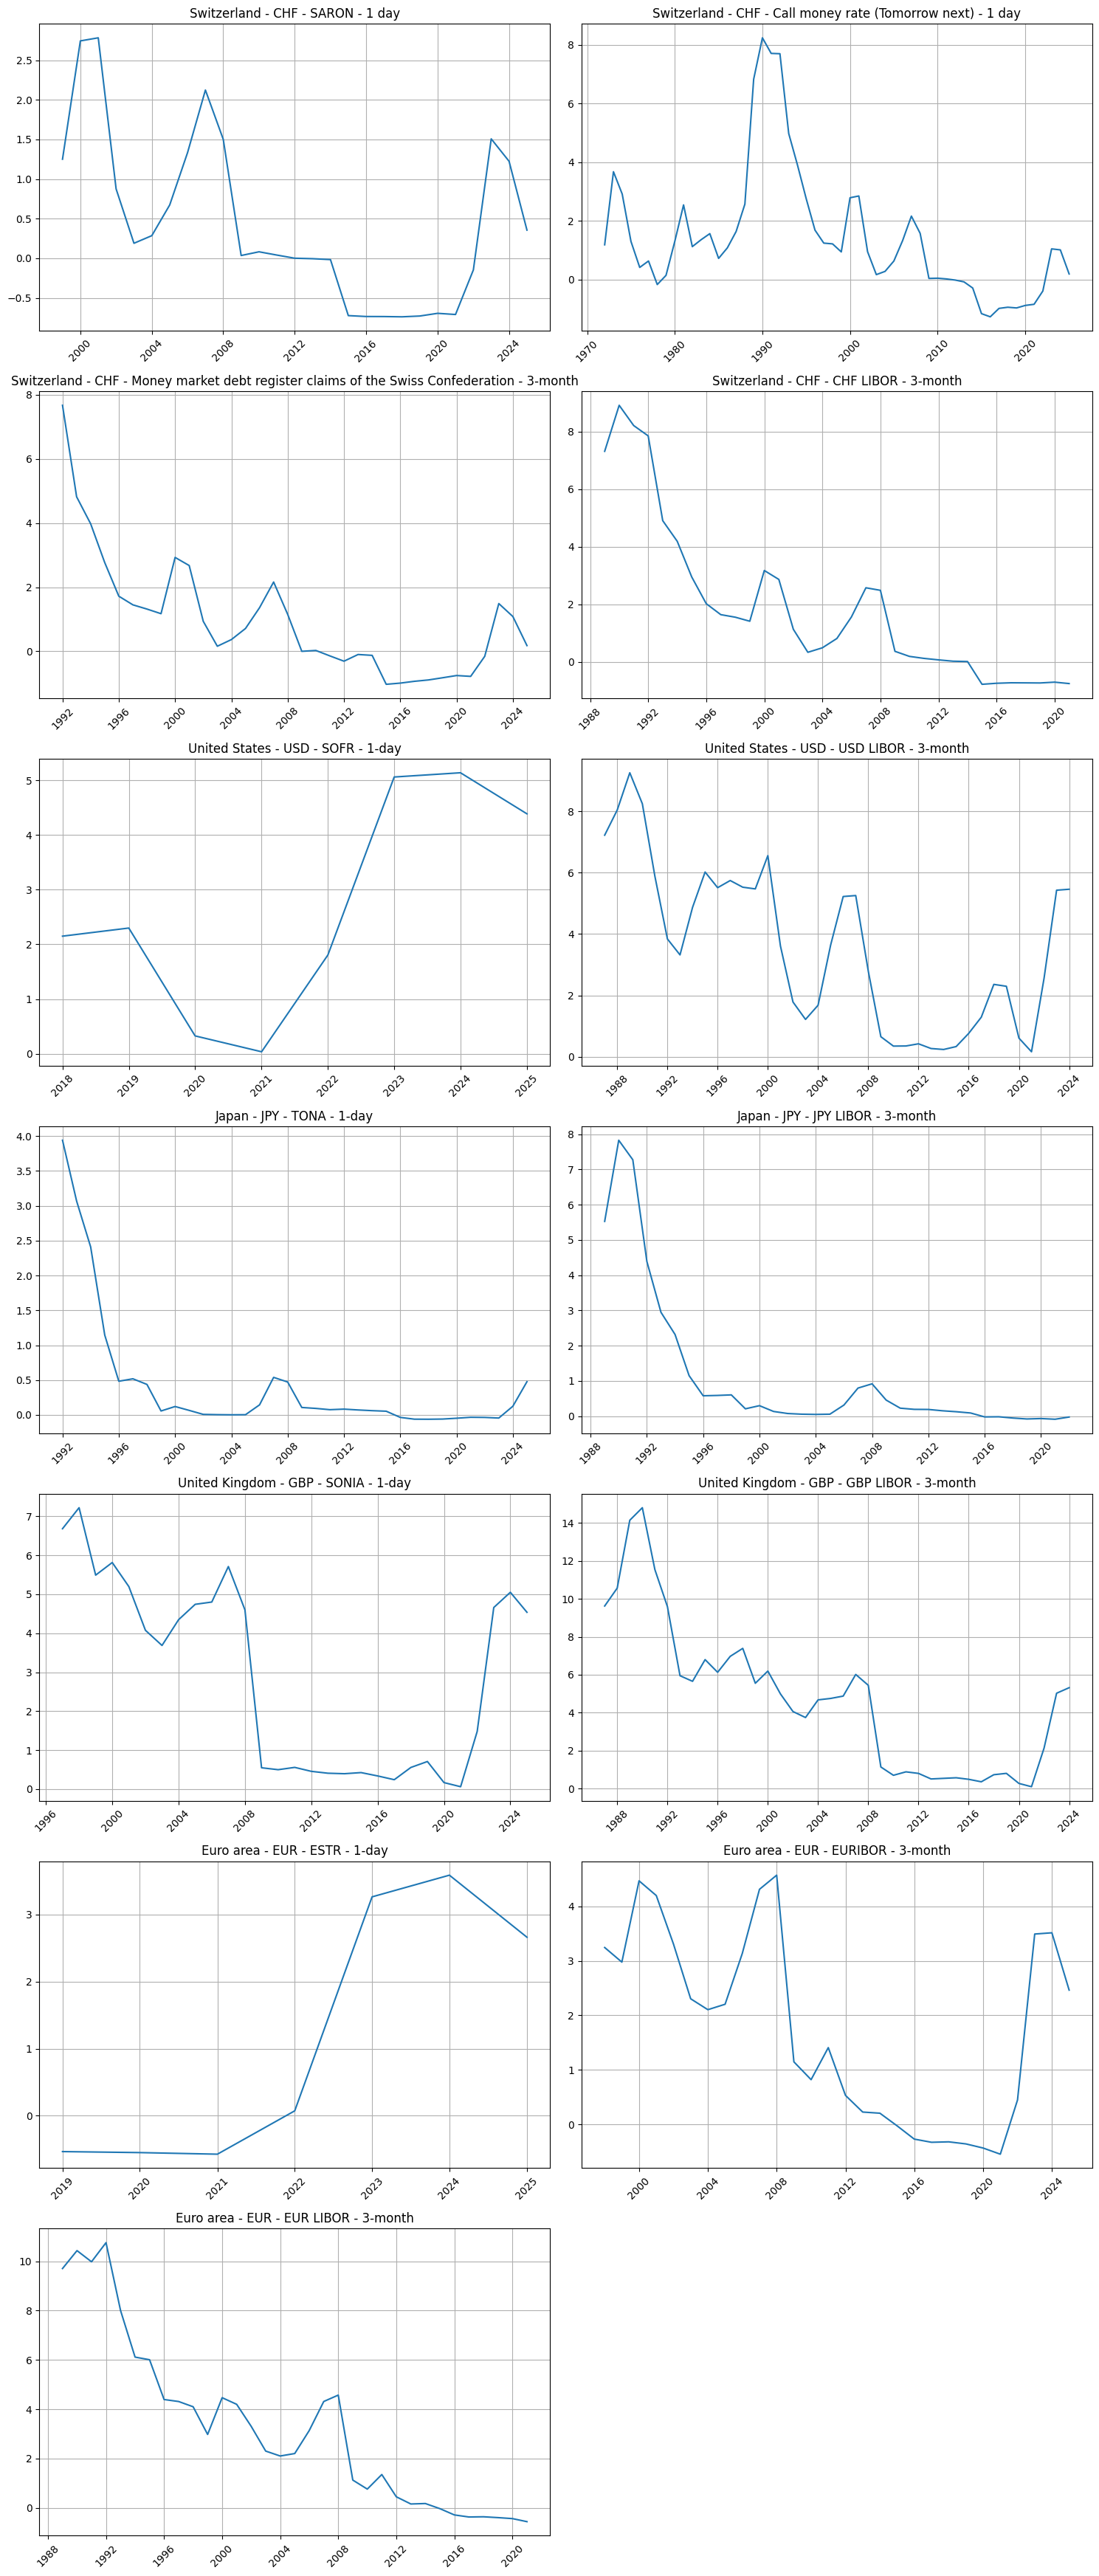

In [4]:
from visualization_function import plot_all_columns

plot_all_columns(yearly_interest_rates_df)

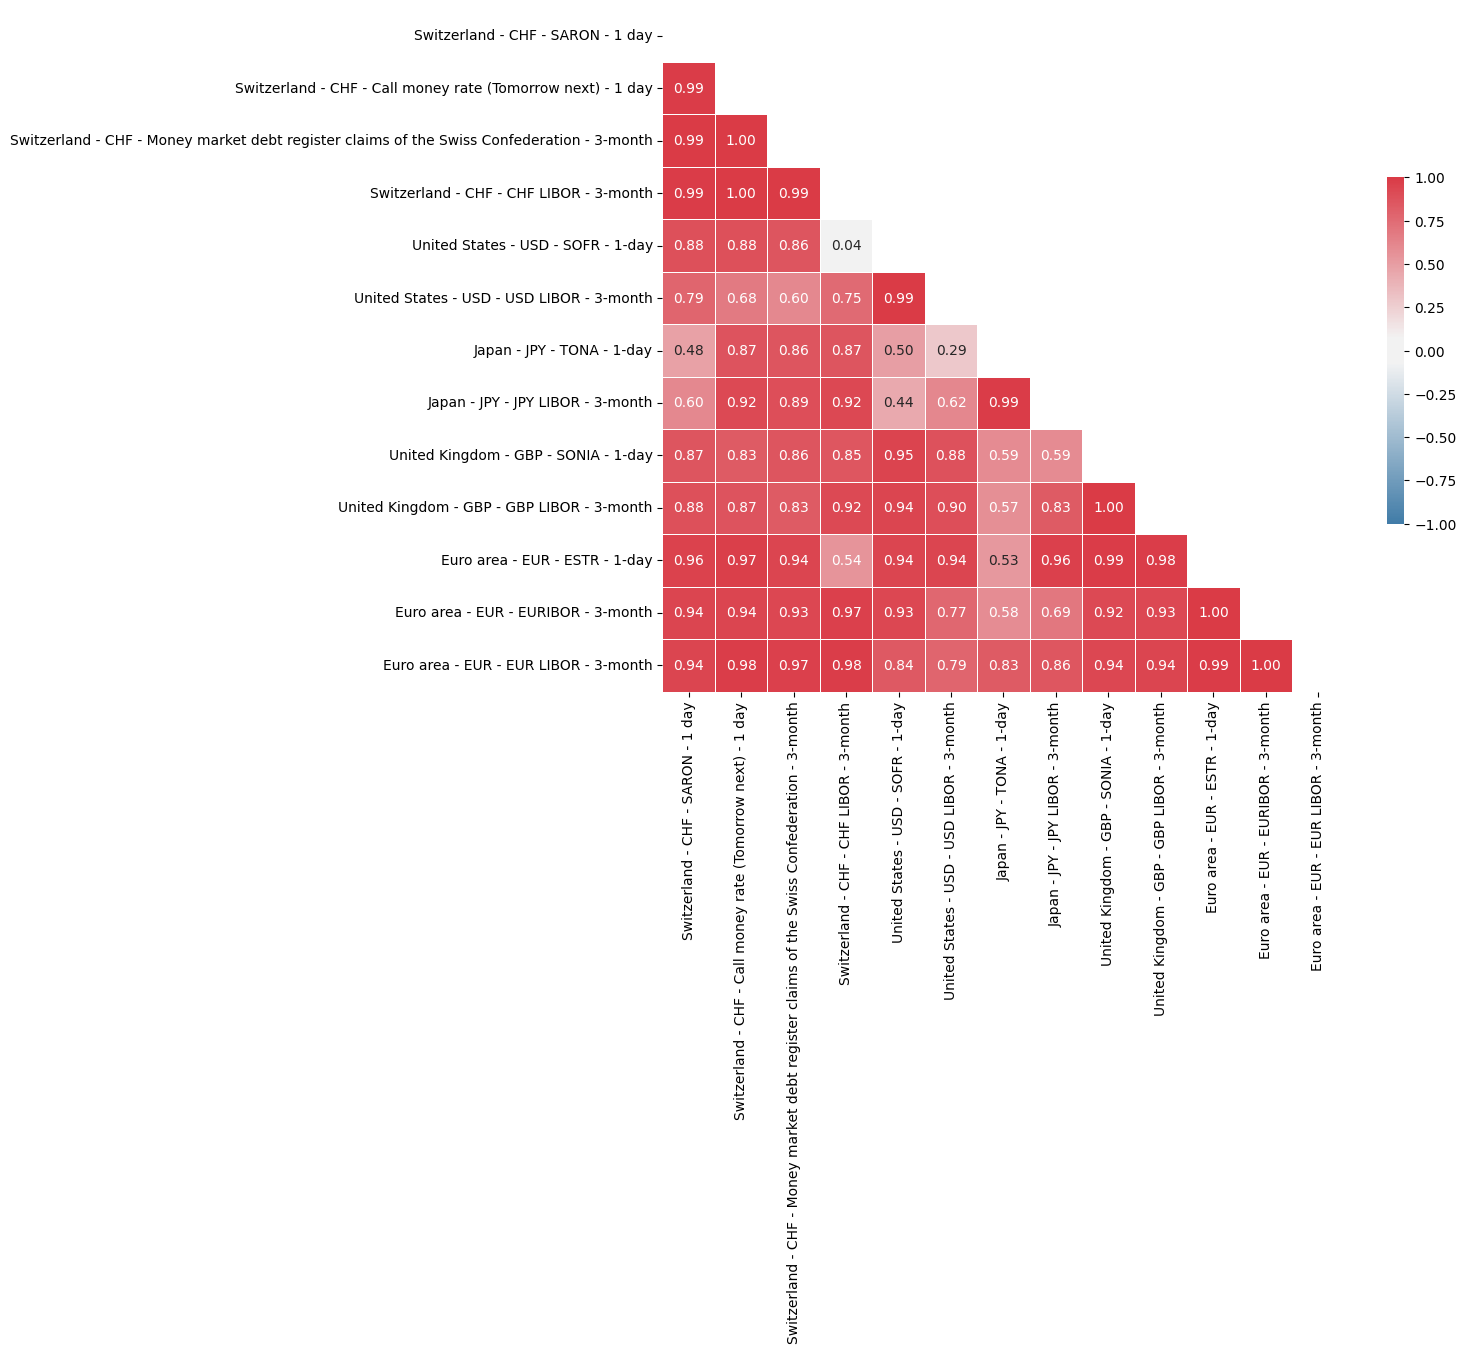

<Axes: >

In [5]:
from visualization_function import plot_correlation_heatmap

plot_correlation_heatmap(yearly_interest_rates_df)

### Monetary base

In [6]:
from data_ingestion import get_and_process_snb_data, group_data_by_year

monthly_monetary_base_df = get_and_process_snb_data(url="https://data.snb.ch/api/cube/snbmoba/data/json/en")
yearly_monetary_base_df = group_data_by_year(monthly_monetary_base_df)
yearly_monetary_base_df.head()

,date,Origination - Relevant foreign currency positions,Origination - Securities portfolio,Origination - Money market transactions,Origination - Other,Origination - Monetary base,Utilisation - Banknotes in circulation,Utilisation - Sight deposit accounts of domestic banks,Utilisation - Monetary base,Seasonally adjusted - Monetary base,Seasonally adjusted - Seasonal factor
0,1950-01-01,NaN,NaN,NaN,NaN,5753.16667,4239.58333,1513.58333,5753.16667,NaN,NaN
1,1951-01-01,NaN,NaN,NaN,NaN,5692.66667,4419.58333,1273.08333,5692.66667,NaN,NaN
2,1952-01-01,NaN,NaN,NaN,NaN,5775.91667,4595.08333,1180.83333,5775.91667,NaN,NaN
3,1953-01-01,NaN,NaN,NaN,NaN,6164.58333,4780.75000,1383.83333,6164.58333,NaN,NaN
4,1954-01-01,NaN,NaN,NaN,NaN,6261.58333,4902.33333,1359.25000,6261.58333,NaN,NaN


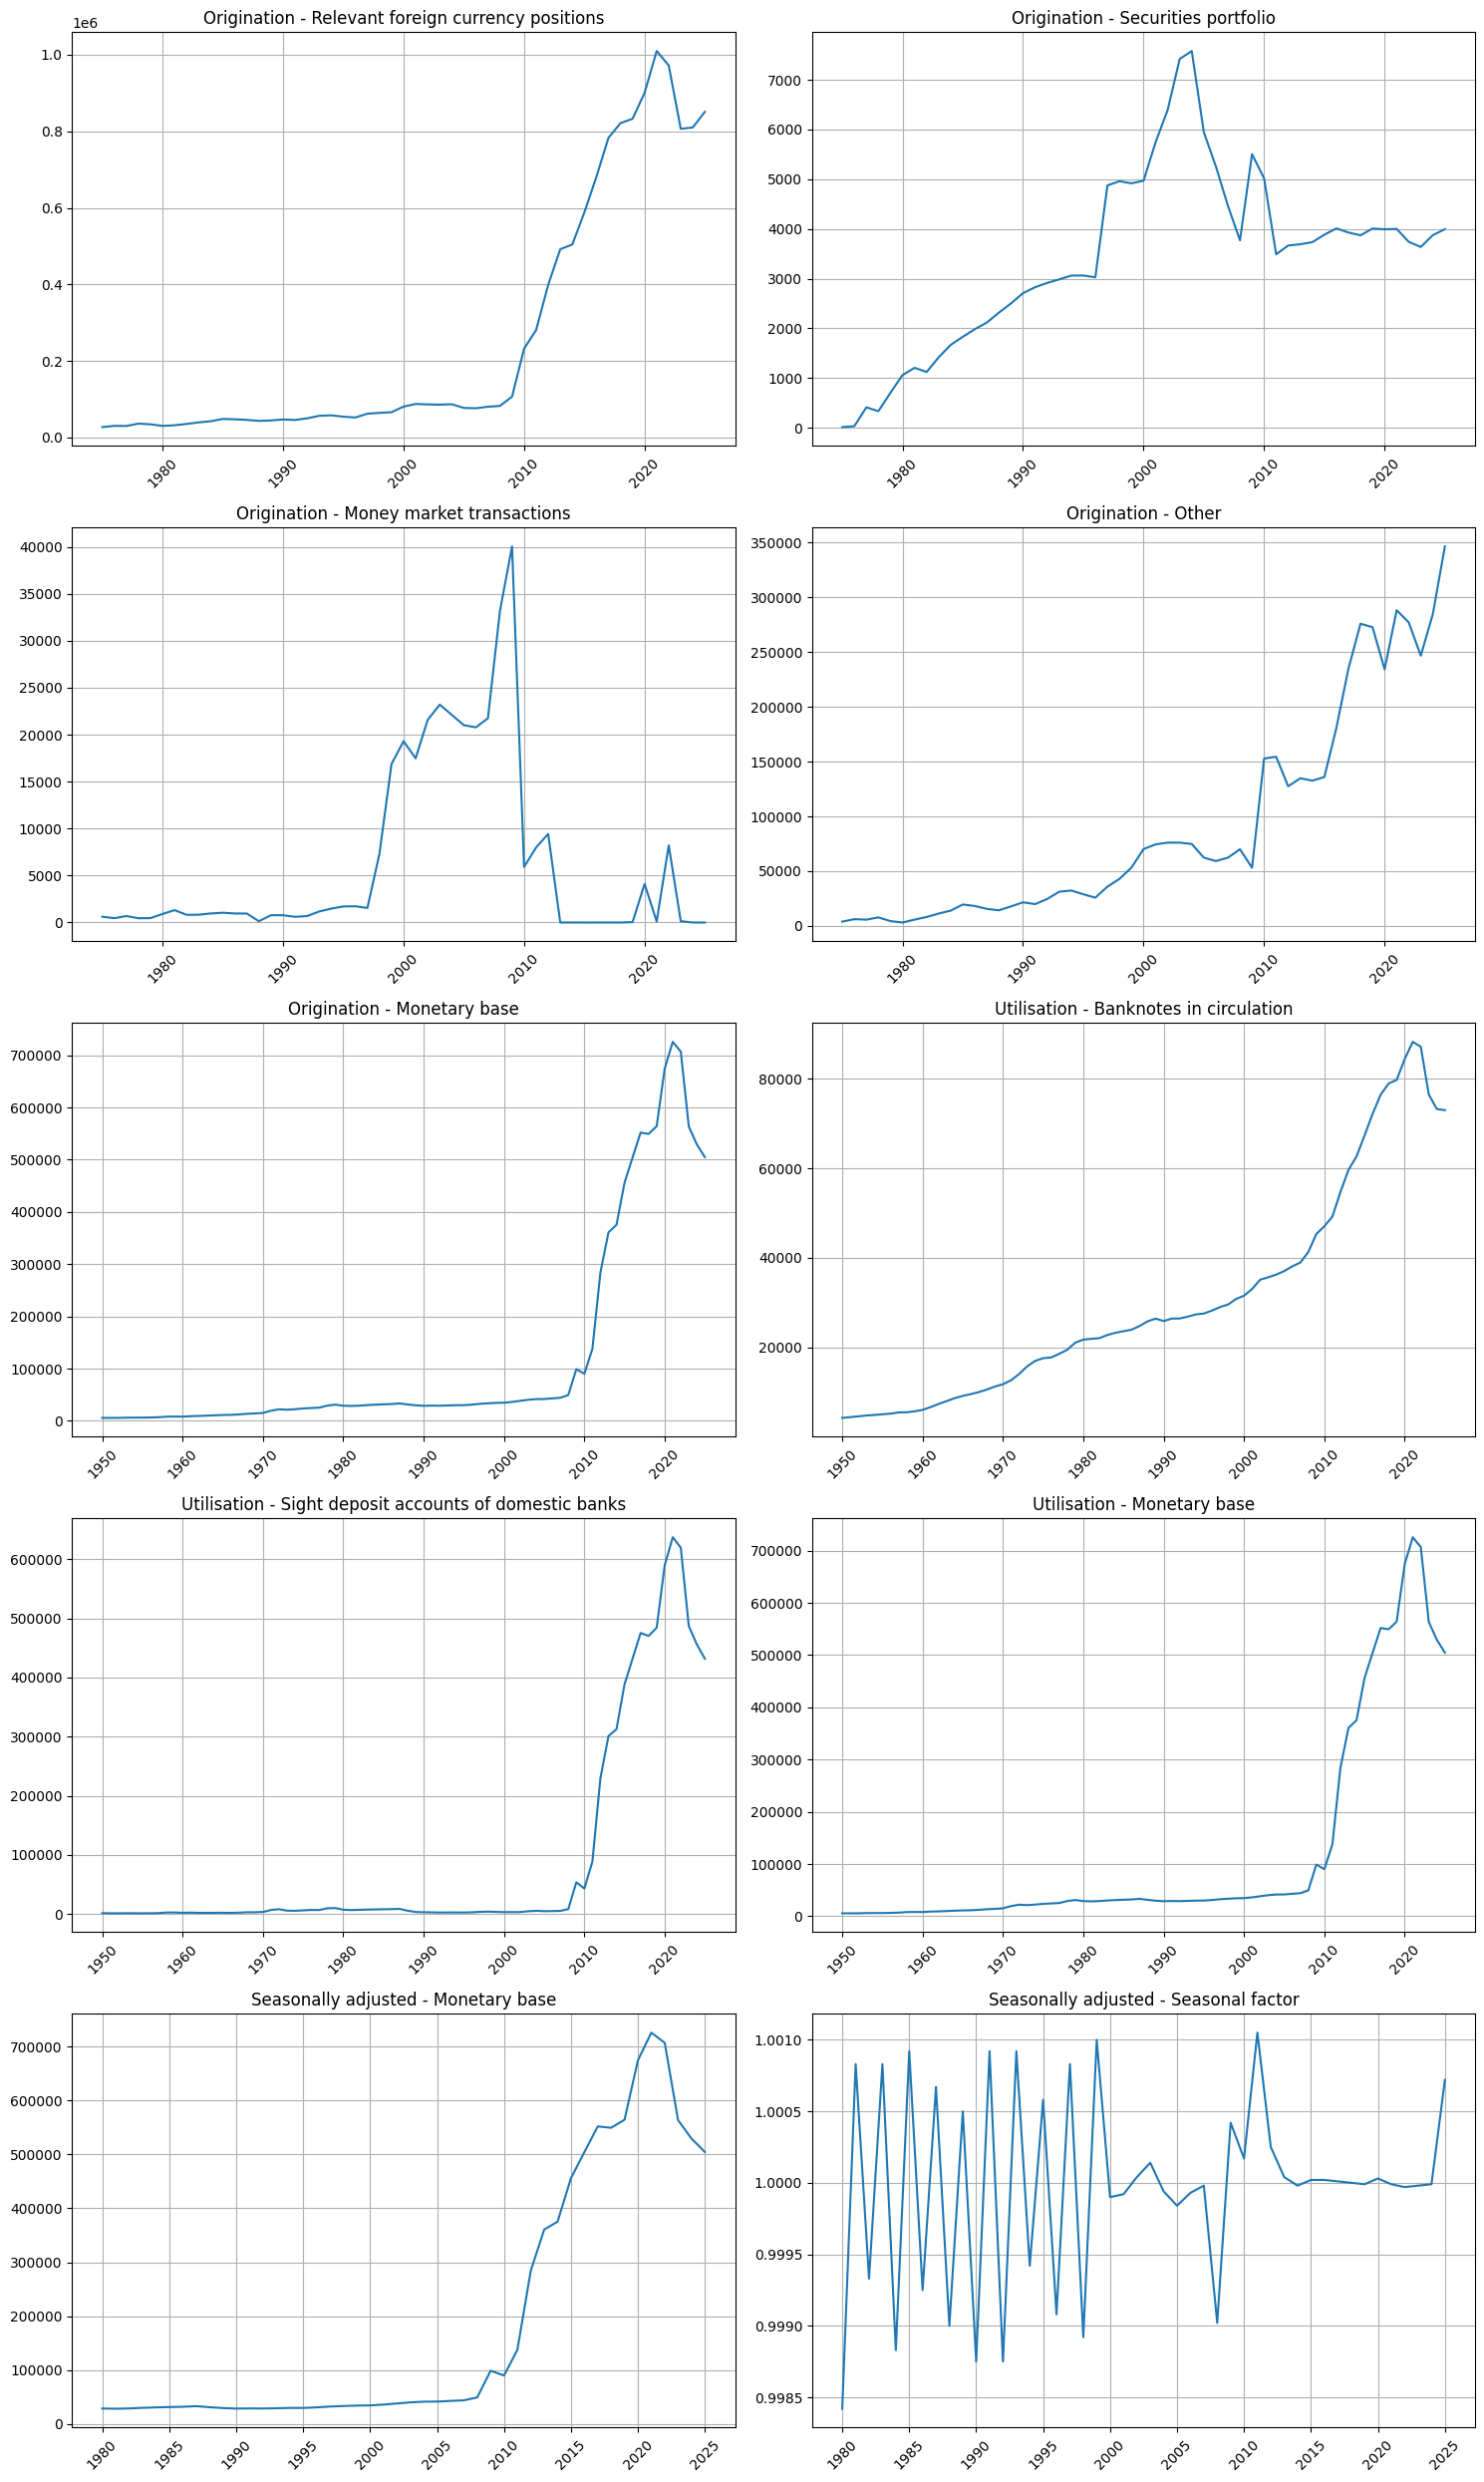

In [7]:
from visualization_function import plot_all_columns

plot_all_columns(yearly_monetary_base_df)

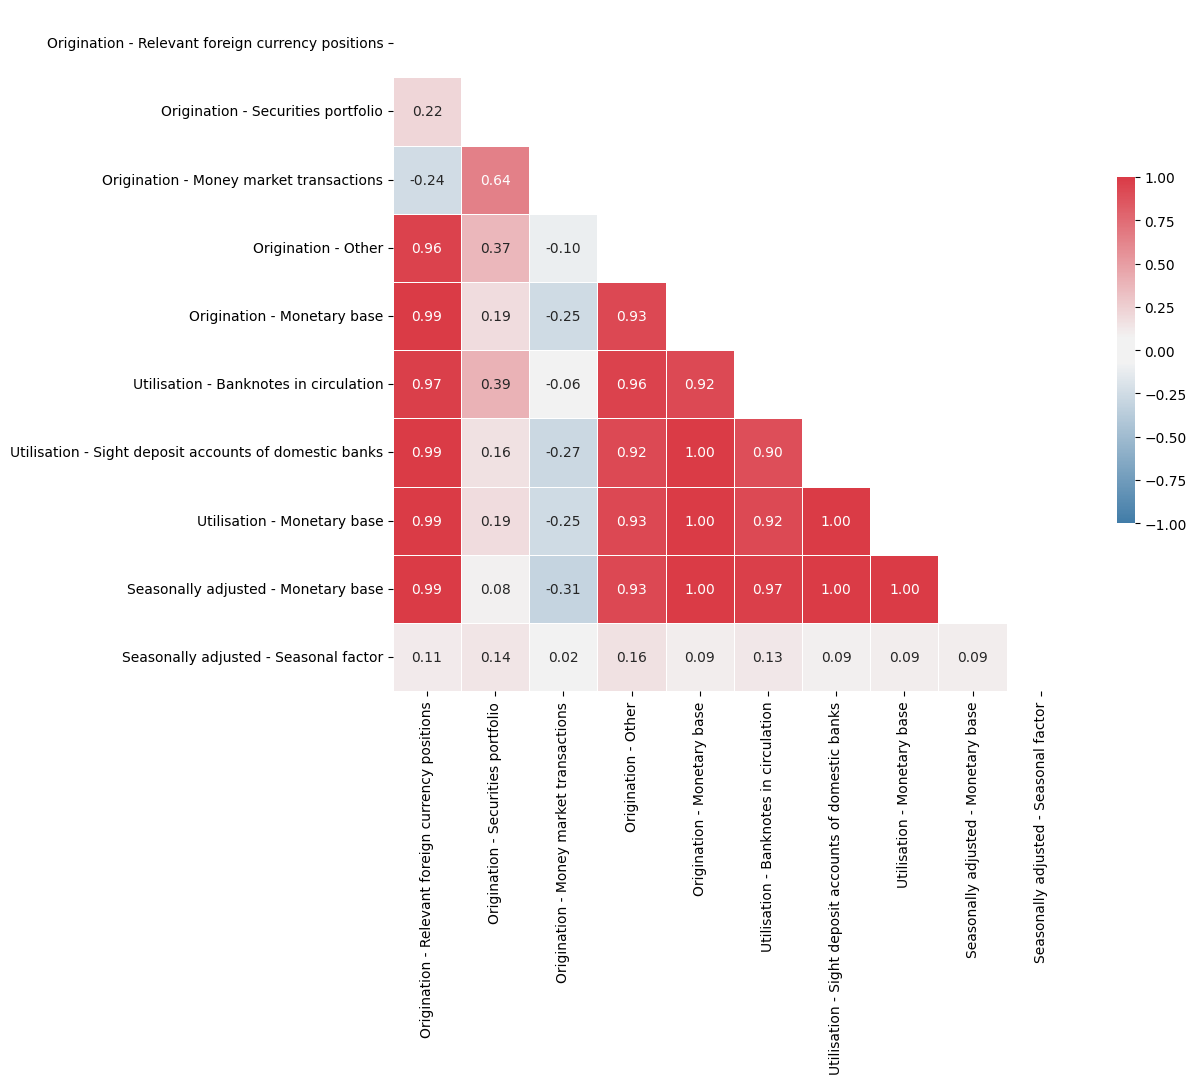

<Axes: >

In [8]:
from visualization_function import plot_correlation_heatmap

plot_correlation_heatmap(yearly_monetary_base_df)

### Monetary aggregates M1, M2 and M3

In [ ]:
from data_ingestion import get_and_process_snb_data_two_header_levels, group_data_by_year

monthly_monetary_aggregate_df = get_and_process_snb_data_two_header_levels(url="https://data.snb.ch/api/cube/snbmonagg/data/json/en")
yearly_monetary_aggregate_df = group_data_by_year(monthly_monetary_aggregate_df)
yearly_monetary_aggregate_df.head()

column_name,date,Change from the corresponding month of the previous year - Currency in circulation,Change from the corresponding month of the previous year - Deposits in transaction accounts,Change from the corresponding month of the previous year - Monetary aggregate M1,Change from the corresponding month of the previous year - Monetary aggregate M2,Change from the corresponding month of the previous year - Monetary aggregate M3,Change from the corresponding month of the previous year - Savings deposits,Change from the corresponding month of the previous year - Sight deposits,Change from the corresponding month of the previous year - Time deposits,Level - Currency in circulation,Level - Deposits in transaction accounts,Level - Monetary aggregate M1,Level - Monetary aggregate M2,Level - Monetary aggregate M3,Level - Savings deposits,Level - Sight deposits,Level - Time deposits
0,1984-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23749.00000,27320.00000,95432.00000,205928.00000,252995.00000,110496.00000,44363.00000,47067.00000
1,1985-01-01,-1.97482,11.89605,4.78456,3.76734,5.89221,2.88879,4.02362,15.18899,22120.58333,28907.66667,92117.66667,202292.16667,258263.25000,110174.50000,41089.41667,55971.08333
2,1986-01-01,1.22039,10.71462,6.78282,6.49869,6.56908,6.26934,7.04556,6.89783,22393.50000,32005.00000,98359.00000,215434.41667,275248.08333,117075.41667,43960.50000,59813.66667
3,1987-01-01,2.68659,14.16789,9.66570,8.46401,9.28115,7.44669,9.95239,12.31777,22991.16667,36555.08333,107906.25000,233703.58333,300854.75000,125797.33333,48360.00000,67151.16667
4,1988-01-01,4.99140,12.48543,13.74221,12.20849,9.64179,10.92412,18.94802,0.74763,24141.08333,41077.25000,122557.66667,262078.25000,329694.66667,139520.58333,57339.33333,67616.41667


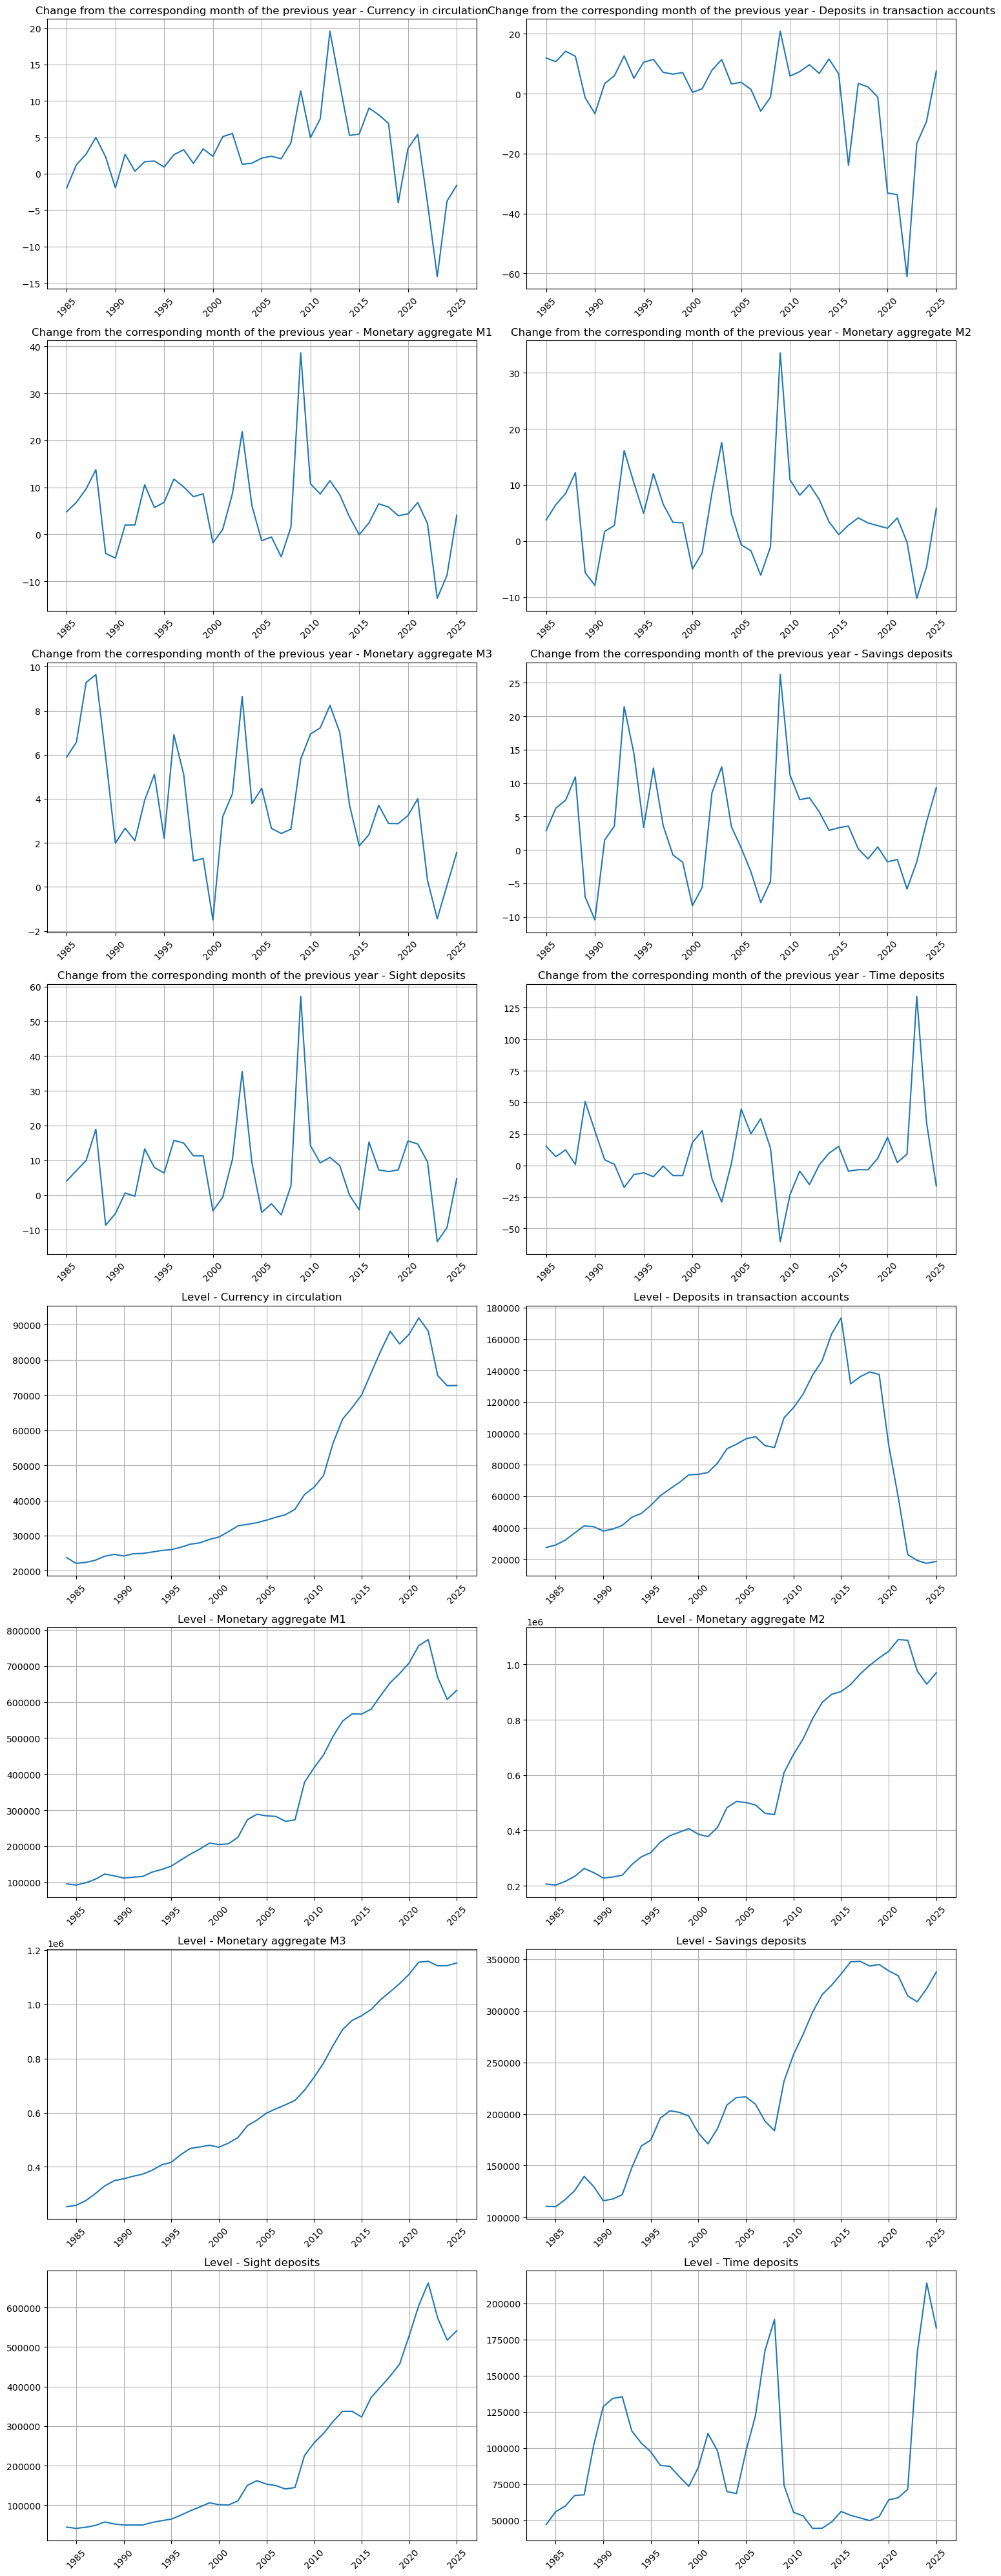

In [ ]:
from visualization_function import plot_all_columns

plot_all_columns(yearly_monetary_aggregate_df)

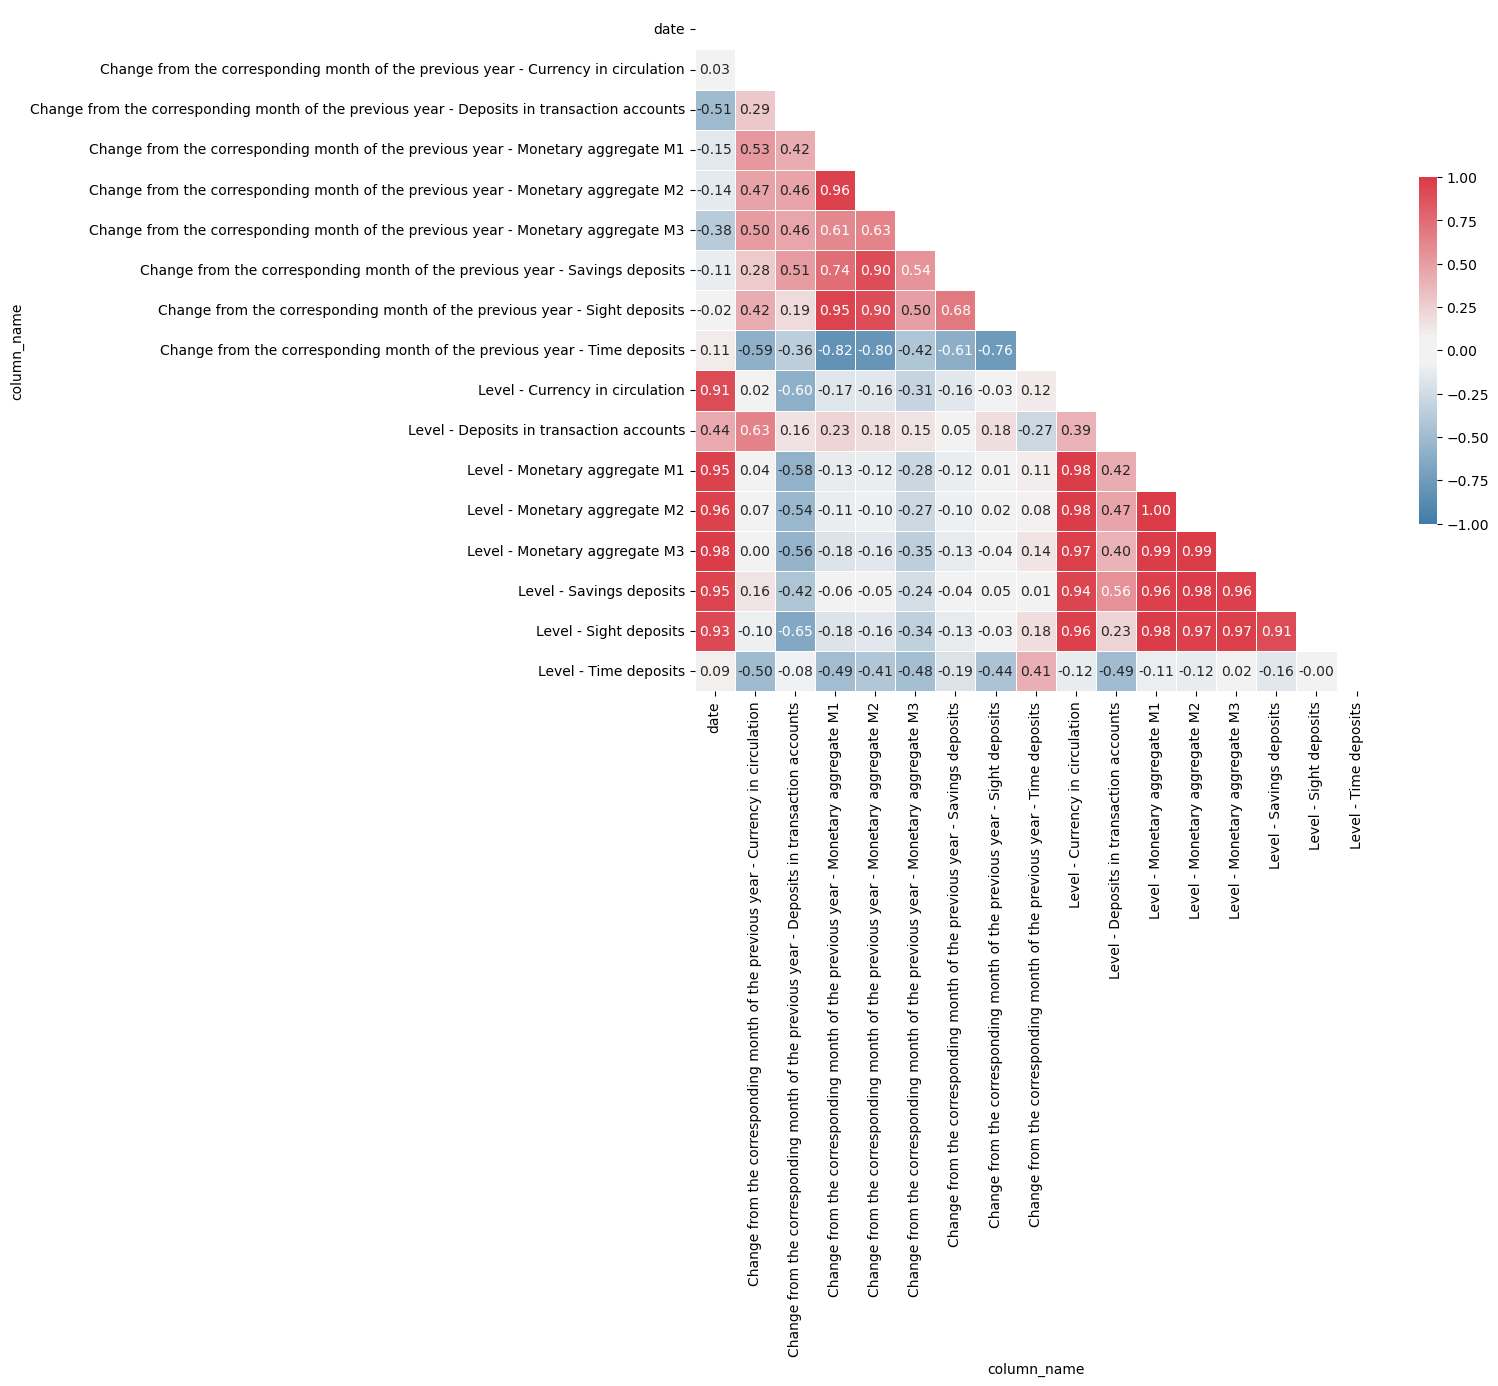

In [ ]:
from visualization_function import plot_correlation_heatmap

plot_correlation_heatmap(yearly_monetary_aggregate_df)

### Mortage data

In [9]:
from data_ingestion import get_and_process_mortgage_data, group_data_by_year

# Process the data
monthly_mortage_df = get_and_process_mortgage_data(url="https://data.snb.ch/api/cube/bakredinausbm/data/json/en")
yearly_mortgage_df = group_data_by_year(monthly_mortage_df)
yearly_mortgage_df.head()


,date,Banks in Switzerland - Total domestic and foreign - Total loans - Utilisation,Banks in Switzerland - Total domestic and foreign - Total loans - Credit lines,Banks in Switzerland - Total domestic and foreign - Mortgage loans - Utilisation,Banks in Switzerland - Total domestic and foreign - Other loans - Total - Utilisation,Banks in Switzerland - Total domestic and foreign - Other loans - secured - Utilisation,Banks in Switzerland - Total domestic and foreign - Other loans - unsecured - Utilisation,Banks in Switzerland - Domestic - Total loans - Utilisation,Banks in Switzerland - Domestic - Total loans - Credit lines,Banks in Switzerland - Domestic - Mortgage loans - Utilisation,Banks in Switzerland - Domestic - Other loans - Total - Utilisation,Banks in Switzerland - Domestic - Other loans - secured - Utilisation,Banks in Switzerland - Domestic - Other loans - unsecured - Utilisation,Banks in Switzerland - Foreign - Total loans - Utilisation,Banks in Switzerland - Foreign - Total loans - Credit lines,Banks in Switzerland - Foreign - Mortgage loans - Utilisation,Banks in Switzerland - Foreign - Other loans - Total - Utilisation,Banks in Switzerland - Foreign - Other loans - secured - Utilisation,Banks in Switzerland - Foreign - Other loans - unsecured - Utilisation
0,1985-01-01,326452.29433,436541.06157,184690.81353,142417.24809,NaN,NaN,275072.21877,358284.62363,183761.06253,91263.42524,NaN,NaN,52723.38943,79305.42455,927.22044,52499.74656,NaN,NaN
1,1986-01-01,346022.90337,464871.66255,198934.41002,147704.52270,NaN,NaN,296800.75291,388304.47895,197990.15722,98752.80468,NaN,NaN,50123.56812,77178.97055,941.50346,49726.94652,NaN,NaN
2,1987-01-01,375319.79601,513436.11961,220442.46006,155436.05964,NaN,NaN,326520.83400,433262.62054,219410.19671,107046.35276,NaN,NaN,49318.68854,80521.09341,1029.05260,48742.37832,NaN,NaN
3,1988-01-01,417393.34659,577566.33419,247768.97916,170188.10179,NaN,NaN,363673.28250,489178.76666,246452.00542,117155.02868,NaN,NaN,54243.56883,88644.65228,1314.11260,53295.10441,NaN,NaN
4,1989-01-01,476823.79185,652310.98007,282922.38214,194555.65786,NaN,NaN,416674.78922,557663.39592,281108.58894,135461.13108,NaN,NaN,60624.86148,94551.16487,1811.91701,59110.59352,NaN,NaN


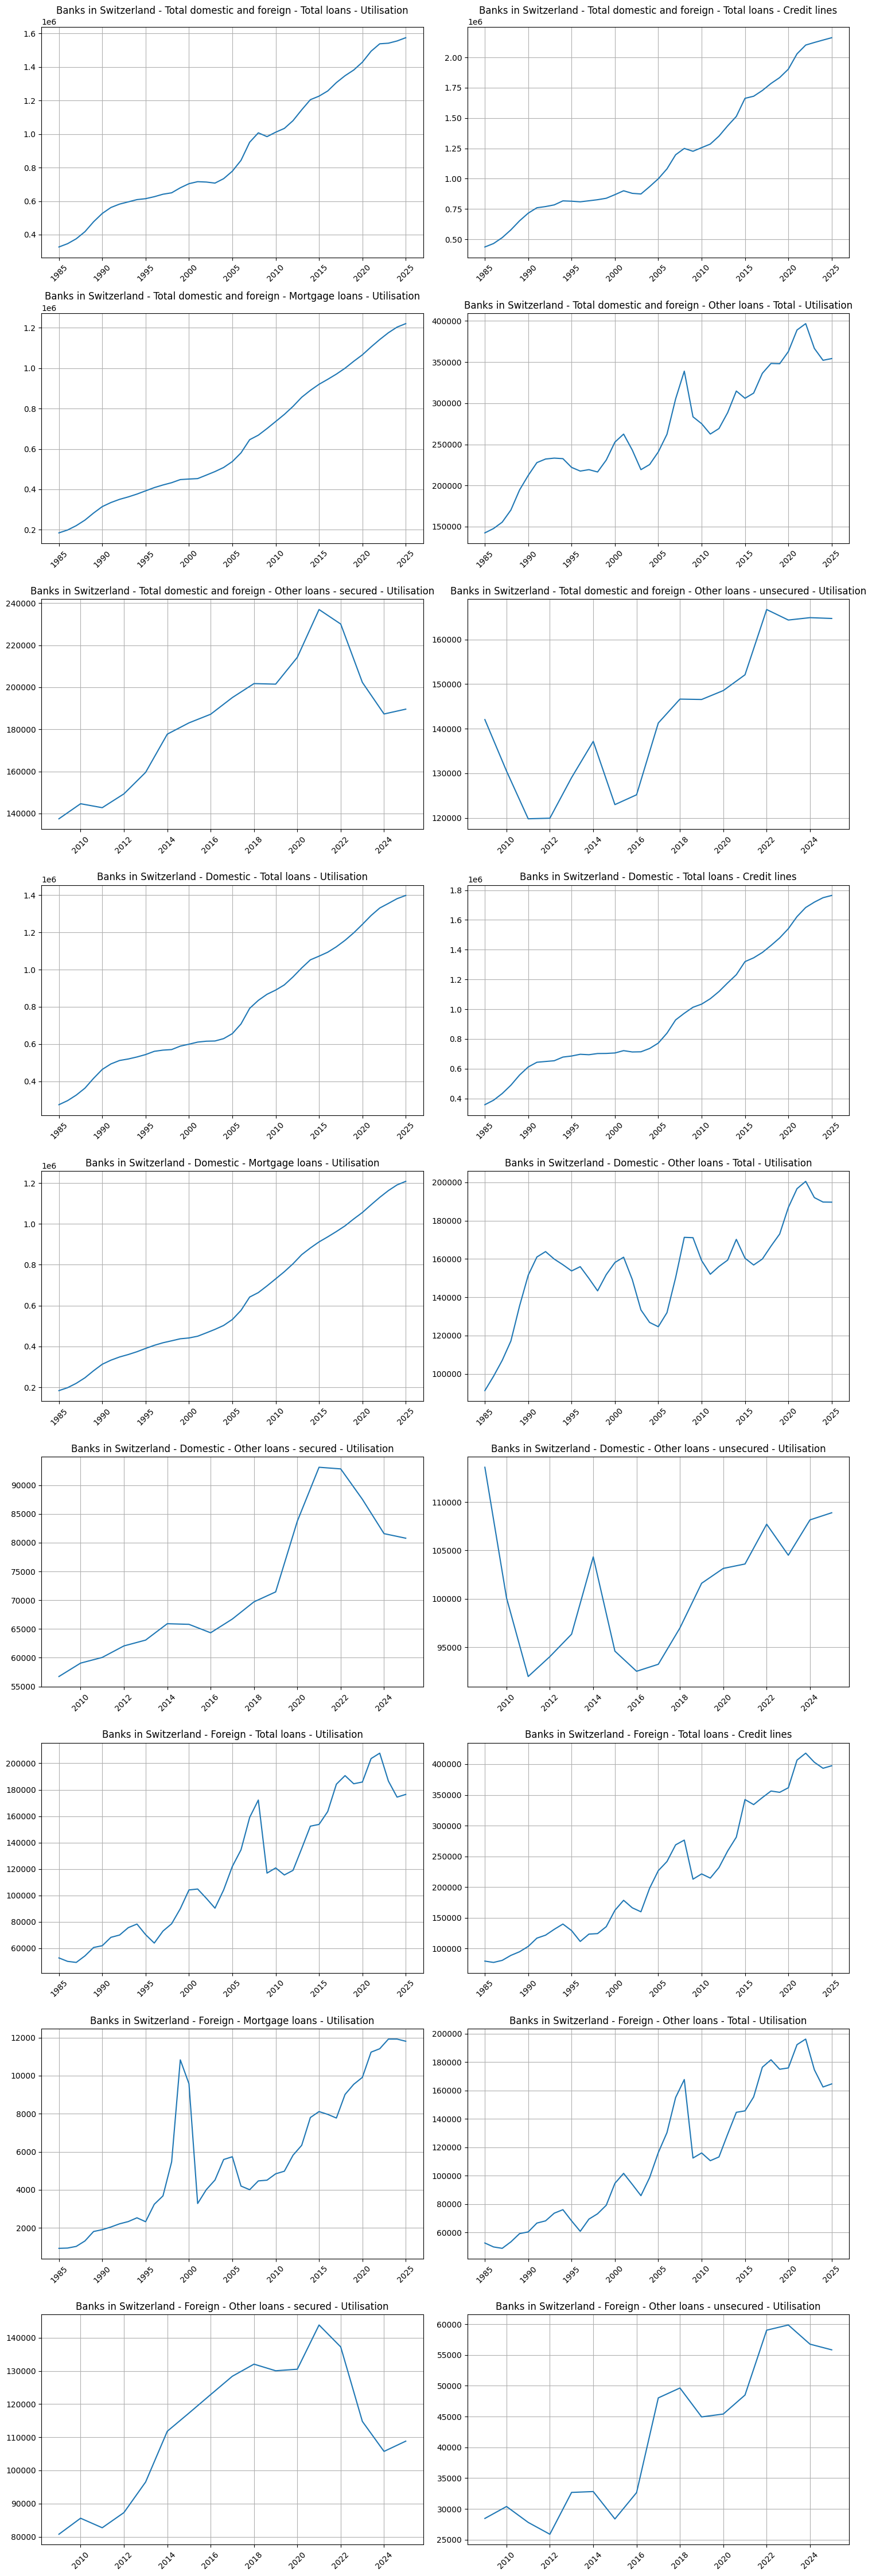

In [10]:
from visualization_function import plot_all_columns

plot_all_columns(yearly_mortgage_df)

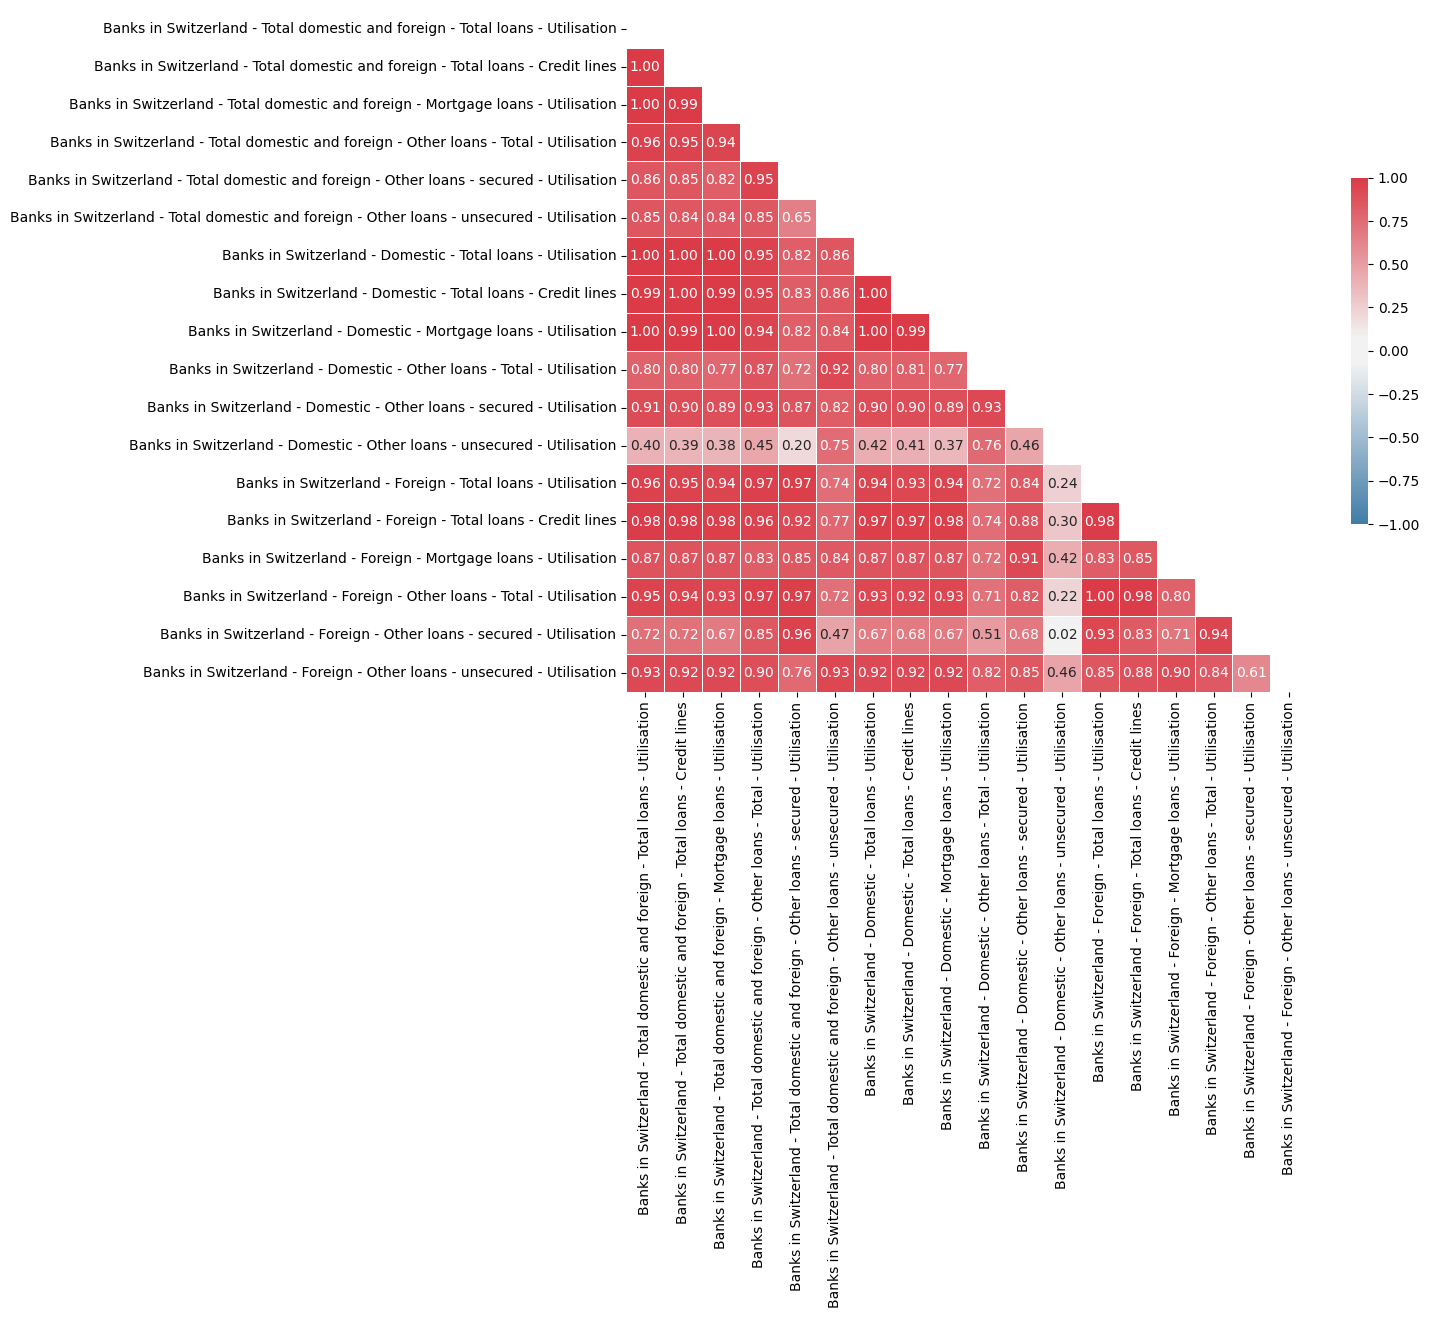

<Axes: >

In [11]:
from visualization_function import plot_correlation_heatmap

plot_correlation_heatmap(yearly_mortgage_df)

### GDP

In [13]:
from data_ingestion import get_and_process_snb_data_two_header_levels, group_data_by_year_sum
import datetime

q_gdp_df = get_and_process_snb_data_two_header_levels(url="https://data.snb.ch/api/cube/gdpgnp/data/json/en")
q_gdp_df = q_gdp_df[['date', 'Value, in CHF millions - Gross domestic product']]
yearly_gdp_df = group_data_by_year_sum(q_gdp_df)
this_year = datetime.datetime.now().year
yearly_gdp_df = yearly_gdp_df[yearly_gdp_df['date'].dt.year != this_year]
yearly_gdp_df.head()

column_name,date,"Value, in CHF millions - Gross domestic product"
0,1990-01-01,369392.22121
1,1991-01-01,385747.93824
2,1992-01-01,393408.66854
3,1993-01-01,401920.59908
4,1994-01-01,412011.52121


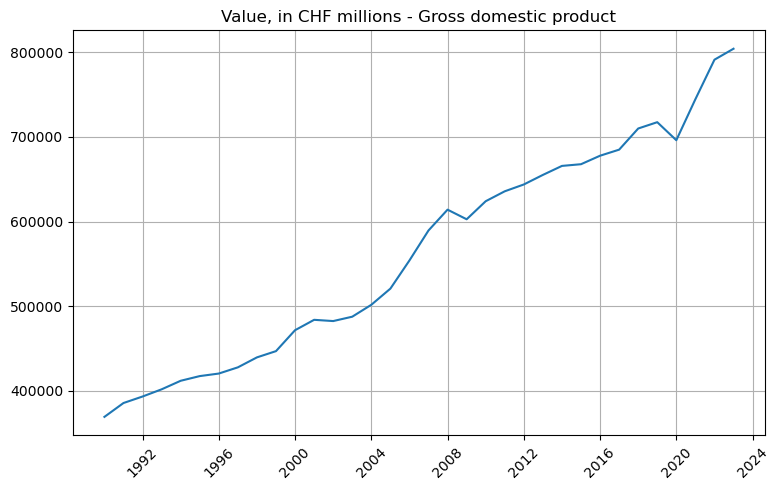

In [ ]:
from visualization_function import plot_all_columns

plot_all_columns(yearly_gdp_df)

## Population size

In [ ]:
from data_ingestion import get_swiss_population_data

population_df = get_swiss_population_data()
population_df

,date,population
0,1960-01-01,5327827.0
1,1961-01-01,5434294.0
2,1962-01-01,5573815.0
3,1963-01-01,5694247.0
4,1964-01-01,5789228.0
...,...,...
59,2019-01-01,8575280.0
60,2020-01-01,8638167.0
61,2021-01-01,8704546.0
62,2022-01-01,8777088.0


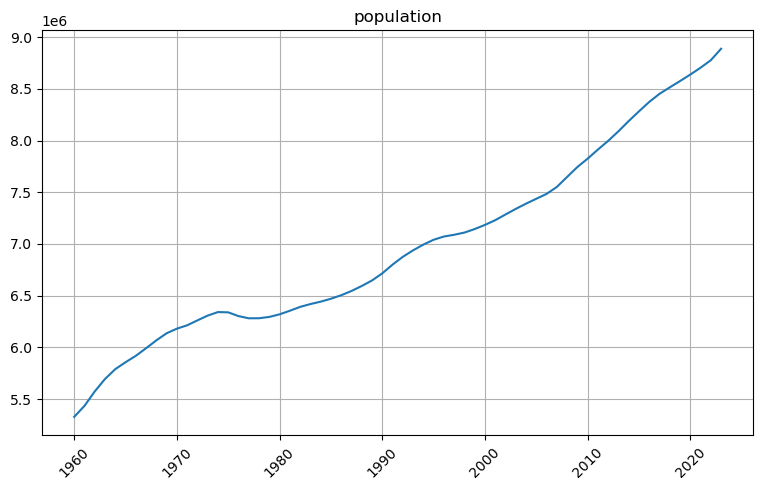

In [ ]:
from visualization_function import plot_all_columns

plot_all_columns(population_df)

## Get inflation data

In [ ]:
from data_ingestion import get_and_process_snb_data, group_data_by_year

monthly_inflation_df = get_and_process_snb_data(url="https://data.snb.ch/api/cube/plkoprinfla/data/json/en")
monthly_inflation_df = monthly_inflation_df[['date', 'SFSO - Inflation according to the national consumer price index']]
inflation_df = group_data_by_year(monthly_inflation_df)
inflation_df.head()

,date,SFSO - Inflation according to the national consumer price index
0,1983-01-01,2.10000
1,1984-01-01,2.94167
2,1985-01-01,3.43333
3,1986-01-01,0.75000
4,1987-01-01,1.45833


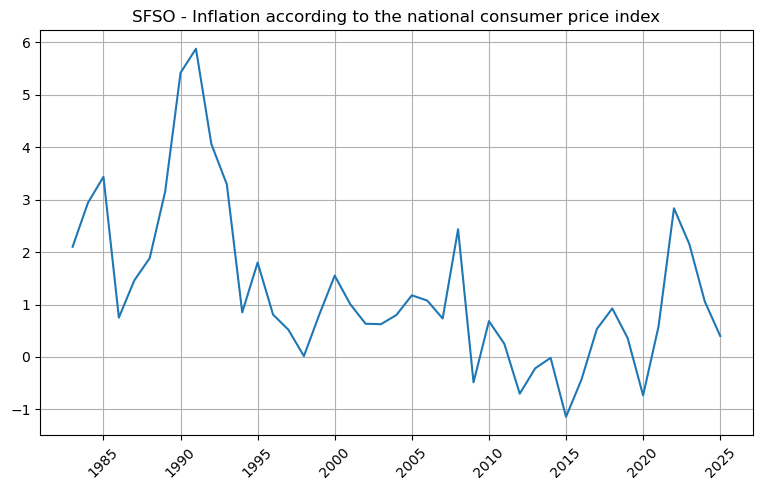

In [ ]:
from visualization_function import plot_all_columns

plot_all_columns(inflation_df)

## Vacancy Rates

In [1]:
from data_ingestion import get_vacancy_rate_data

df_1 = get_vacancy_rate_data()
df_1.head()

,date,vacancy_rate
7,1980,0.740
8,1981,0.550
9,1982,0.670
10,1983,0.714
11,1984,0.758


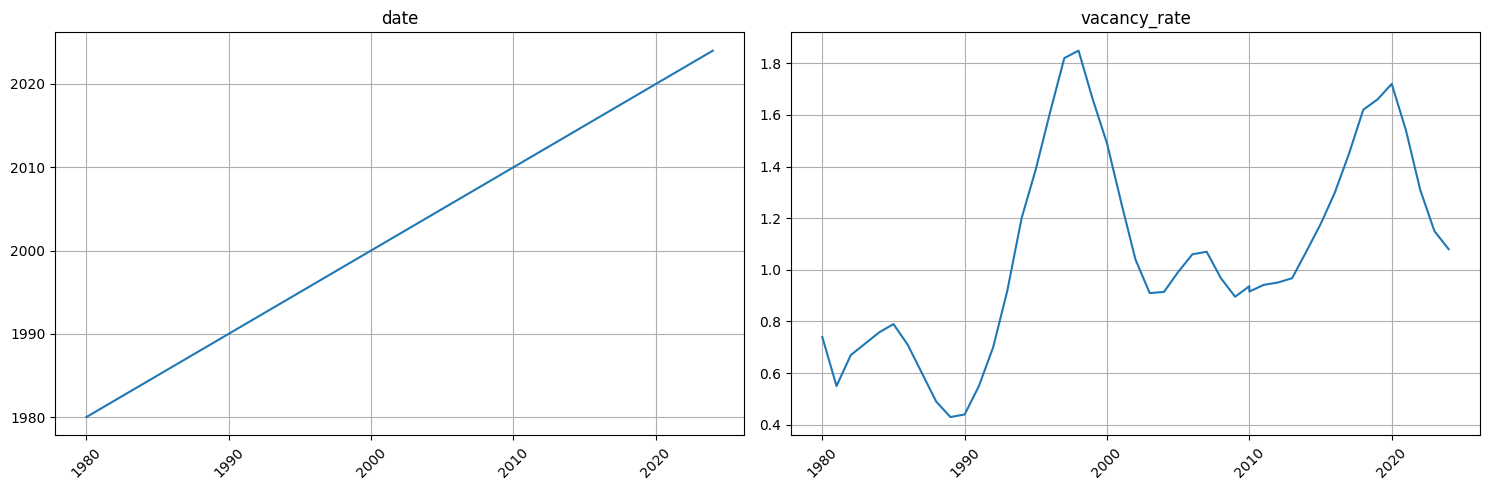

In [6]:
from visualization_function import plot_all_columns

plot_all_columns(df_1)

## New housing construction

In [7]:
from data_ingestion import get_new_housing_construction_data

housing_construction_df = get_new_housing_construction_data()

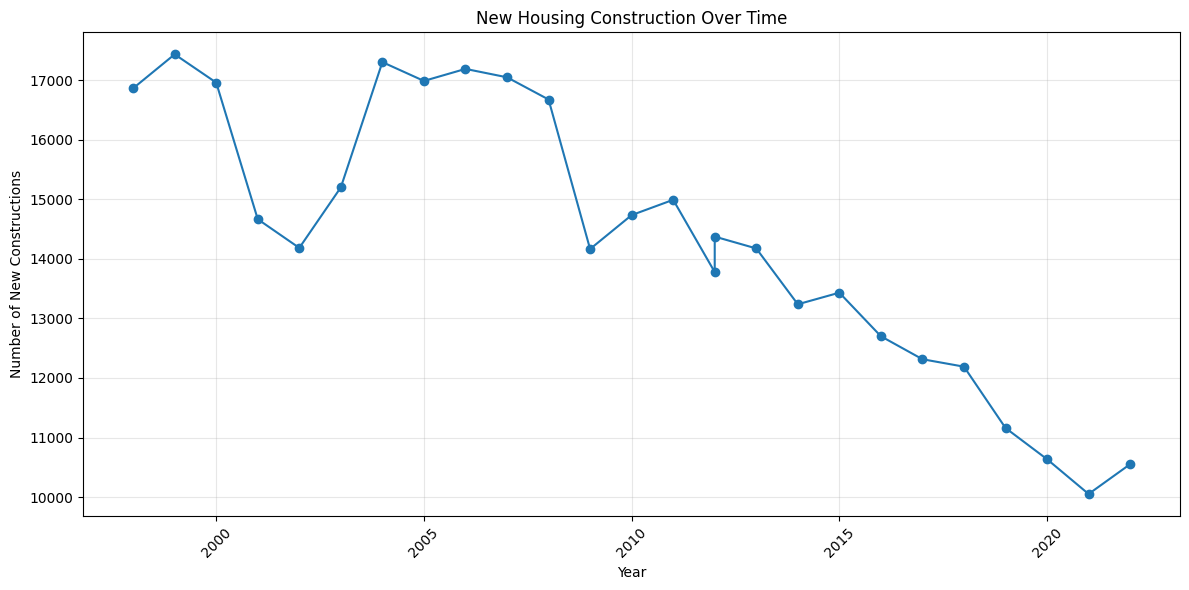

In [8]:
# Create a line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(housing_construction_df['date'], housing_construction_df['new_constructions'], marker='o', linestyle='-')
plt.title('New Housing Construction Over Time')
plt.xlabel('Year')
plt.ylabel('Number of New Constructions')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Urban Population

In [1]:
from data_ingestion import get_urban_population_data

urban_population_df = get_urban_population_data()
urban_population_df.head()

,date,pop_in_agglomeration
1,1991,5011.723
2,1992,5047.044
3,1993,5080.221
4,1994,5110.744
5,1995,5138.142


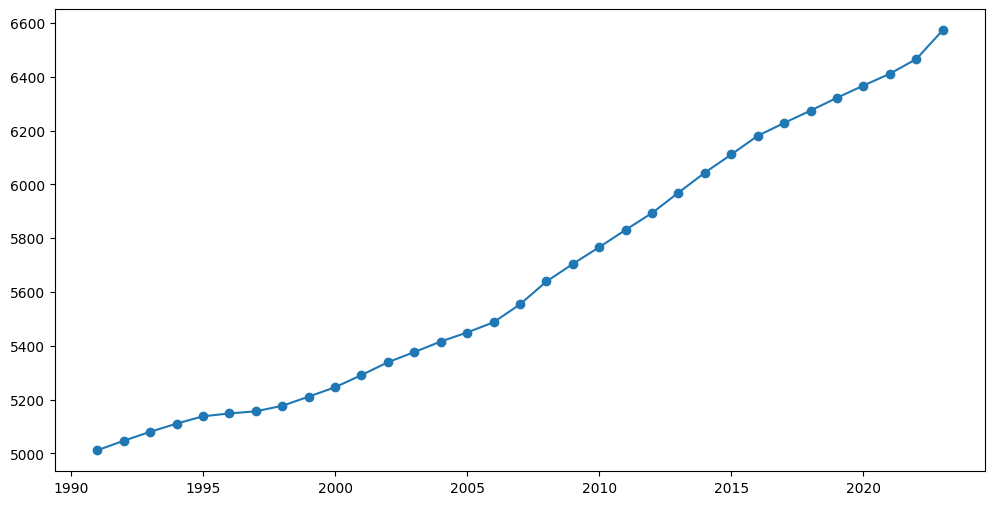

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(urban_population_df['date'], urban_population_df['pop_in_agglomeration'], marker='o', linestyle='-')

## Divorces

In [1]:
from data_ingestion import get_divorce_data

divorces_df = get_divorce_data()
divorces_df.head()

indicator,date,Divorces - Total
0,1876,1102.0
1,1877,1036.0
2,1878,1036.0
3,1879,938.0
4,1880,856.0


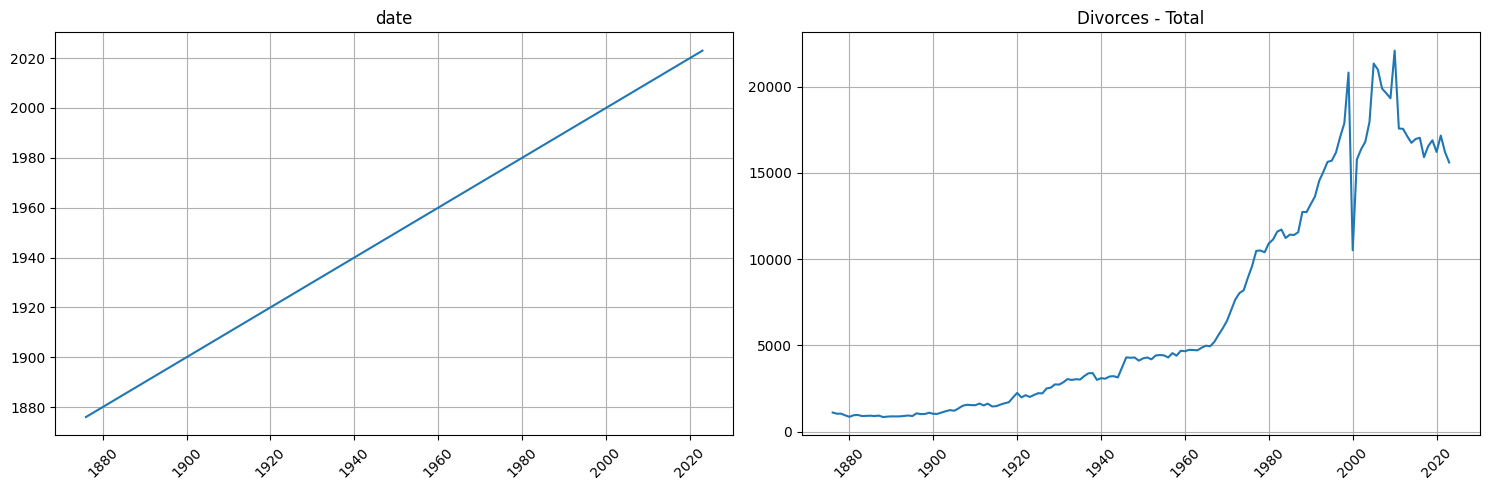

In [2]:
from visualization_function import plot_all_columns
plot_all_columns(divorces_df)
